## Predict lakes on a new-area cube with the model trained in 2_segment_lakes.

Prereq: build newarea_cube.zarr exactly as 1_load_lake_cube.ipynb does
(same to_reflectance, same BAND_NAMES order, same TARGET_CRS/RES) but with
the new BBOX.

Everything about the model contract - band order, normalisation, architecture -
is read from unet_lake.pt, so it cannot drift out of sync with training.

In [4]:
import numpy as np
import xarray as xr
import rioxarray  # noqa: registers .rio accessor
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
PROJECT_ROOT = Path(r"D:\Users\b1120440\projects\morpheo\glacial_lake_pred")

CUBE = PROJECT_ROOT / "east_cube.zarr"
CKPT = PROJECT_ROOT / "unet_lake.pt"
THRESHOLD = 0.5

### Load cube & model

In [6]:
cube = xr.open_zarr(CUBE)
if cube.rio.crs is None:                       # zarr could lose the CRS
    cube = cube.rio.write_crs("EPSG:32627")

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)

BANDS = ckpt["bands"]                          # e.g. ['blue','green','nir','red']
print("model expects bands:", BANDS)
print("normalization     :", ckpt.get("normalization", "(not recorded)"))
missing = [b for b in BANDS if b not in cube.data_vars]
assert not missing, f"cube is missing {missing}; has {list(cube.data_vars)}"

model = smp.Unet(**ckpt["arch"], encoder_weights=None)
model.load_state_dict(ckpt["state_dict"])
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("device:", device)

# ------------------------------------------------------------------
# Normalisation contract - MUST match training exactly.
#   new checkpoints: per-scene percentile standardisation
#   old checkpoints: fixed per-band mean/std
#   older still    : none at all (raw reflectance)
# ------------------------------------------------------------------
STD_CFG = ckpt.get("standardize")
if STD_CFG is not None:
    PLOW, PHIGH = STD_CFG["p_low"], STD_CFG["p_high"]
    CLIP = tuple(STD_CFG["clip"])
    MODE = "per_scene"
    print(f"normalisation: per-scene p{PLOW:g}-p{PHIGH:g}, clipped {CLIP}")
elif "norm_mean" in ckpt and "norm_std" in ckpt:
    MEAN = np.array(ckpt["norm_mean"], "float32")[:, None, None]
    STD  = np.array(ckpt["norm_std"],  "float32")[:, None, None]
    MODE = "fixed"
    print("normalisation: fixed per-band mean/std")
else:
    MEAN = np.zeros((len(BANDS), 1, 1), "float32")
    STD  = np.ones((len(BANDS), 1, 1), "float32")
    MODE = "fixed"
    print("normalisation: none recorded -> identity (raw reflectance)")

model expects bands: ['blue', 'green', 'nir', 'red']
normalization     : reflectance 0-1, then per-scene per-band p2-p98 scaling, clipped [-0.5,1.5]
device: cuda
normalisation: per-scene p2-p98, clipped (-0.5, 1.5)


### Build the image stack in the model's band order

In [7]:
img = (cube[BANDS].to_array("band")
       .transpose("year", "band", "y", "x").values.astype("float32"))
valid = np.isfinite(img).all(axis=1)        # (year, y, x) - all bands present
img = np.nan_to_num(np.clip(img, 0, 1))     # same as training

print("reflectance median per band:",
      [round(float(np.nanmedian(img[:, i][img[:, i] > 0])), 4) for i in range(len(BANDS))])


def standardize_scene(a, good):
    """a: (band, y, x) reflectance; good: (y, x) bool. Identical to training."""
    out = np.empty_like(a, dtype="float32")
    for b in range(a.shape[0]):
        v = a[b][good]
        v = v[np.isfinite(v)]
        if v.size < 100:
            out[b] = 0.0
            continue
        lo, hi = np.percentile(v, [PLOW, PHIGH])
        out[b] = (a[b] - lo) / (hi - lo + 1e-6)
    return np.clip(out, *CLIP).astype("float32")


if MODE == "per_scene":
    # cloud is excluded from the percentile estimate when the cube carries it,
    # exactly as in training
    cloud = (cube["cloud"].values.astype(bool) if "cloud" in cube.data_vars
             else np.zeros_like(valid, bool))
    for t in range(img.shape[0]):
        good = valid[t] & (~cloud[t])
        if good.sum() < 100:
            good = valid[t]
        img[t] = standardize_scene(img[t], good)

    print("standardised median per band (compare with the training printout):")
    for t in [0, len(img)//2, len(img)-1]:
        med = [round(float(np.median(img[t, b][valid[t]])), 3) for b in range(len(BANDS))]
        print(f"   {int(cube.year.values[t])}  {med}")

years = [int(y) for y in cube.year.values]


@torch.no_grad()
def predict(t: int) -> np.ndarray:
    a = img[t] if MODE == "per_scene" else (img[t] - MEAN) / STD
    x = torch.from_numpy(a).unsqueeze(0).to(device)
    _, _, Y, X = x.shape
    x = F.pad(x, (0, (32 - X % 32) % 32, 0, (32 - Y % 32) % 32))
    return torch.sigmoid(model(x))[0, 0, :Y, :X].cpu().numpy()

reflectance median per band: [0.1026, 0.1227, 0.2385, 0.1282]
standardised median per band (compare with the training printout):
   1985  [0.214, 0.224, 0.274, 0.223]
   2001  [0.059, 0.076, 0.206, 0.087]
   2026  [0.058, 0.058, 0.217, 0.074]


### Predict every year

In [8]:
probs = []
px_km2 = abs(float(cube.x[1] - cube.x[0])) * abs(float(cube.y[1] - cube.y[0])) / 1e6
print(f"\n{'year':6}{'max':>8}{'frac>thr':>10}{'area km2':>10}")
for t, yr in enumerate(years):
    p = np.where(valid[t], predict(t), np.nan)
    probs.append(p)
    lake = (p > THRESHOLD) & valid[t]
    print(f"{yr:<6}{np.nanmax(p):8.3f}{lake.mean():10.4f}{lake.sum() * px_km2:10.3f}")
probs = np.stack(probs)


year       max  frac>thr  area km2
1985     1.000    0.0015     1.518
1986     1.000    0.0049     4.951
1987     1.000    0.0093     9.397
1988     1.000    0.0151    15.380
1989     1.000    0.0091     9.226
1990     1.000    0.0055     5.584
1991     1.000    0.0186    18.846
1992     0.822    0.0000     0.004
1993     0.965    0.0001     0.103
1994     1.000    0.0053     5.365
1995     1.000    0.0050     5.102
1996     1.000    0.0166    16.838
1997     1.000    0.0135    13.676
1998     1.000    0.0010     0.969
1999     1.000    0.0104    10.514
2000     1.000    0.0067     6.847
2001     1.000    0.0039     3.974
2002     1.000    0.0308    31.235
2009     0.883    0.0000     0.020
2013     1.000    0.0071     7.186
2014     1.000    0.0141    14.270
2015     1.000    0.0153    15.567
2016     1.000    0.0149    15.142
2017     1.000    0.0146    14.868
2018     1.000    0.0106    10.719
2019     1.000    0.0193    19.601
2020     1.000    0.0230    23.344
2021     1.000    0

### Save & plot

In [9]:
out = xr.Dataset(
    {"prob": (("year", "y", "x"), probs.astype("float32")),
     "lake": (("year", "y", "x"), (probs > THRESHOLD).astype("uint8")),
     "valid": (("year", "y", "x"), valid.astype("uint8"))},
    coords={"year": years, "y": cube.y, "x": cube.x},
).rio.write_crs(cube.rio.crs or "EPSG:32627")
out.to_zarr(str(PROJECT_ROOT / "new_area_predictions.zarr"), mode="w")

C:\Users\b1120440\AppData\Local\miniconda3\envs\eocube\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [10]:
# # GeoTIFF of the last year, for QGIS
# ti = len(years) - 1
# out["prob"].isel(year=ti).rio.to_raster(PROJECT_ROOT / f"newarea_prob_{ti}.tif")
# print(f"wrote newarea_prob_{years[ti]}.tif")

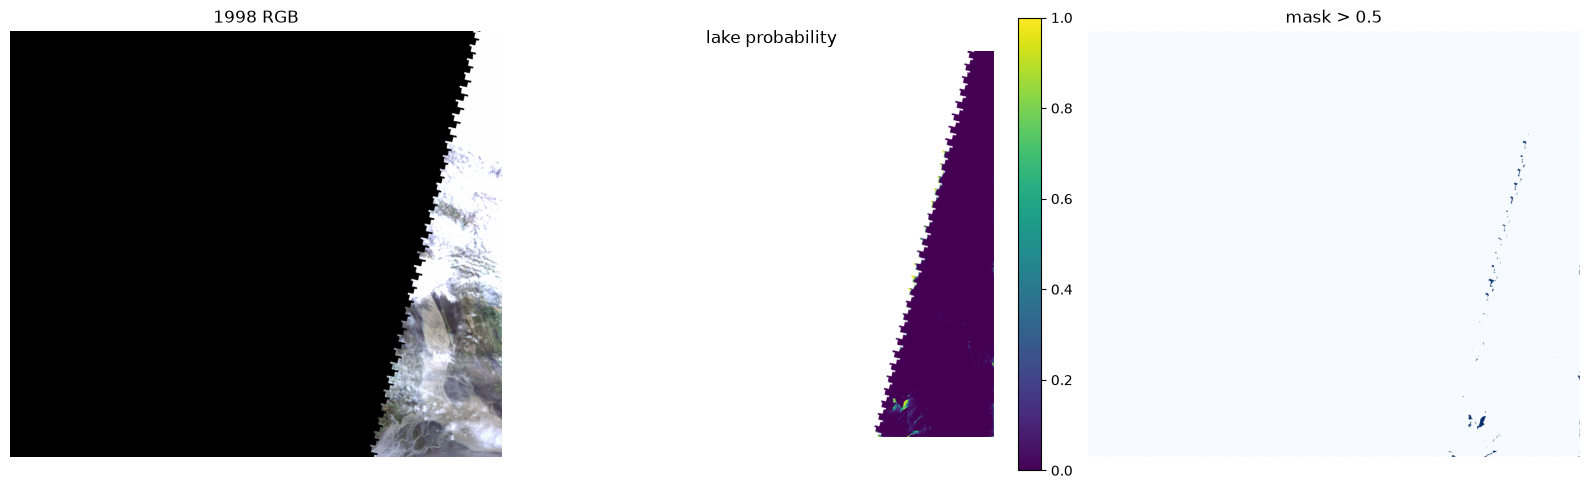

In [30]:
def rgb(t, p=(2, 98)):
    i = {b: k for k, b in enumerate(BANDS)}
    a = np.dstack([img[t, i["red"]], img[t, i["green"]], img[t, i["blue"]]])
    lo, hi = np.nanpercentile(a, p)
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

# show the year with the strongest detection rather than a fixed offset
t = int(np.nanargmax([np.nanmax(p) for p in probs]))
t = 13
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(rgb(t));                            ax[0].set_title(f"{years[t]} RGB")
im = ax[1].imshow(probs[t], vmin=0, vmax=1);     ax[1].set_title("lake probability")
fig.colorbar(im, ax=ax[1], fraction=0.046)
ax[2].imshow(probs[t] > THRESHOLD, cmap="Blues"); ax[2].set_title(f"mask > {THRESHOLD}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()